We want to feed more characters in, not just 3. 
We don't want to feed all of them into a single layer, because that squashes too many of them too quickly. 
Instead, we want a deeper model that progressively diffuses the information to make the next guess.  
We'll arrive at something that looks like the wavenet paper -   
  

Convoutional nets allows you to apply the for loop in a linear filter in space over the input data (???)

We've "pytorchified" the code by writing the classes. We've 'unlocked' torch.nn. Modules are working on torch.tensor.  

The development of building deep NN:  
-lots of time in the pytorch documentaiton pages: shapes of inputs, what can they be, what do they do.  


In [21]:
import os
os.chdir('/Users/alexanderhannah/Desktop/Github-projects/nn-zero-to-hero')

In [22]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
# read in the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [24]:
# build the vocabulary of charcters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [25]:
# shuffle the words
import random
random.seed(42)
random.shuffle(words)

In [70]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [71]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [111]:
# Let's train a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:

    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # different behavior if you're training or evaluating (loss or test examples)
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        # buffers are not part of backprob/gradient descent. The running mean/var is trained 'internally'
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training: # when we're training, we use the mean/sd from the current batch
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim = True)
            xvar = x.var(dim, keepdim = True)
        else: # in testing, we use the running mean/var
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers only when training
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape # 4, 8, 10
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get parameters of all layers and stretch out into one list
        return [p for layer in self.layers for p in layer.parameters()]

In [112]:
torch.manual_seed(42);

In [ ]:
n_embd = 24 # dimension of the character embedding vectors
n_hidden = 128 # number of nuerons in the hidden layer of the MLP

# 6 layer MLP
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), 
])

# parameter init
with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22397


In [103]:
# Scratch
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0, 13,  1, 18,  9,  3,  5, 12],
        [ 0,  0,  0,  0,  0, 26,  8, 21],
        [ 0,  0,  0,  0,  0,  0,  0, 18],
        [ 0,  0,  0,  0,  0,  0,  0, 10]])

In [104]:
# scratch
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [ ]:
# Scratch
model.layers[0].out.shape # output of Embedding layer: for each character, we have a 10 int embedding layer; 
# the model translates this into 4 (batch size) x 8 (character block size) x 10 (embedding layer)


torch.Size([4, 8, 10])

In [ ]:
# Scratch
# after flatten, views the 8x10 embedding layer as 80 
model.layers[1].out.shape

torch.Size([4, 80])

In [ ]:
# Scratch
# After linear layer, this takes the 80 and creates 200 channels using matrix multiplication
model.layers[2].out.shape

torch.Size([4, 200])

In [ ]:
# scratch
# the 4 x 10 input being multiplied does not need to be 2D. You can pass a higher dimensional tensor
(torch.rand(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape # (4, 200) original
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape # (4, 4, 200)

torch.Size([4, 4, 200])

In [ ]:
e = torch.randn(4, 8, 10) # goal: want this to be (4, 4, 20) where consecutive 10-dimensional vectors get concatenated
e[:, ::2, :], e[:, 1::2, :] # just even element
torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim = 2).shape
e.view(4, 4, 20) == torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim = 2)


tensor([[[True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [True, True, True, True, True, True, True, True, True, True, True,
          True, True, True, True, True, True, True, True, True],
         [T

In [ ]:
# 1 2 3 4 5 6 7 8
# we don't want flatten this into a 8 length vector. we want to group them by twos
# {1 2} {3 4} {5 6} {7 8} process these in parallel


In [114]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.5 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.6368
  10000/ 200000: 2.3267
  20000/ 200000: 2.0770
  30000/ 200000: 2.0441
  40000/ 200000: 2.0252
  50000/ 200000: 2.3216
  60000/ 200000: 2.0350
  70000/ 200000: 1.9447
  80000/ 200000: 1.8529
  90000/ 200000: 2.1128
 100000/ 200000: 1.6787
 110000/ 200000: 2.3342
 120000/ 200000: 2.4476
 130000/ 200000: 1.9283
 140000/ 200000: 2.1056
 150000/ 200000: 1.7250
 160000/ 200000: 1.9706
 170000/ 200000: 2.1344
 180000/ 200000: 2.2093
 190000/ 200000: 1.8624


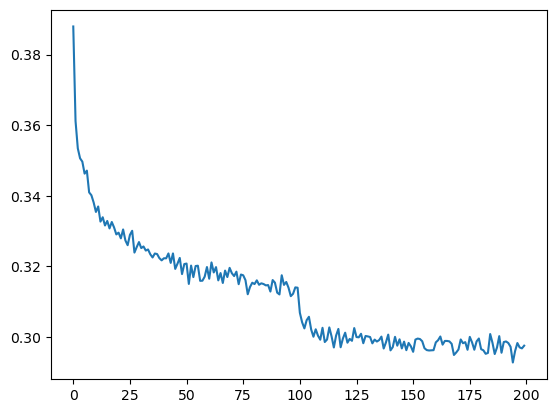

In [115]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [116]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [117]:
# evaluate the loss
@torch.no_grad() # tell pytorch not to track gradients; saves memory
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), 
        'test': (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y) # cross entropy between logits and true labels
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9645969867706299
val 2.042895555496216


Performance log. 
  
original (3 character context + 200 hidden neurons, 12K params): train 2.06, val 2.1. 
context: 3 -> 8 (22k params): train 1.9, val 2.0. names look a bit better.  
layered architecture: train 2.0, val 2.05




In [78]:
# sample from the model

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the NN
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

tedpelyn.
emmalana.
arislea.
edharin.
nuhora.
nahkan.
helek.
hanor.
fraisay.
inabelli.
alina.
srydel.
nilliine.
melai.
sayleo.
dypyn.
auzan.
kaleempra.
eramer.
jaisanis.
